# Probabilistic Forecasting: Conformal Calibration

Conformal prediction is a framework for constructing prediction intervals that are guaranteed to contain the true value with a specified probability (coverage probability). This guarantee is marginal (it holds on average over many predictions, not for each individual one) and assumes that the data are exchangeable. In addition to generating prediction intervals from point forecasts, conformal methods can also calibrate intervals produced by other techniques, such as quantile regression or bootstrapped residuals. In such cases, the conformal method adjusts the intervals, either expanding or shrinking them, to ensure they achieve the desired coverage.

<p style="text-align: center">
    <img src="../img/conformal-interval-calibration.png" style="width: 450px">
    <br>
    <font size="2.5"> 
        <i>
        Conformal calibration of prediction intervals. Source: 
            <a href="https://leanpub.com/conformal-prediction" target="_blank"> 
                Introduction To Conformal Prediction With Python: A Short Guide For Quantifying Uncertainty Of Machine Learning Models 
            </a> 
        by Christoph Molnar
        </i>
    </font>
</p>

Skforecast provides this functionality through the [`ConformalIntervalCalibrator`](https://skforecast.org/latest/api/preprocessing#skforecast.preprocessing._preprocessing.ConformalIntervalCalibrator) transformer that can be used for single series forecasting models as well as global forecasting models.

<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161; Tip</b>
</p>

<p>For more examples on how to use probabilistic forecasting, check out the following articles:</p>
<ul>
    <li>
        <a href="https://cienciadedatos.net/documentos/py42-probabilistic-forecasting" target="_blank">
            Probabilistic forecasting with machine learning
        </a>
    </li>
    <li>
        <a href="https://cienciadedatos.net/documentos/py60-probabilistic-forecasting-prediction-intervals-multi-step-forecasting" target="_blank">
            Probabilistic forecasting: prediction intervals for multi-step time series forecasting
        </a>
    </li>
    <li>
        <a href="../faq/probabilistic-forecasting-crps-score.html" target="_blank">
            Continuous Ranked Probability Score (CRPS) in probabilistic forecasting
        </a>
    </li>
</ul>

</div>

In [1]:
# Data processing
# ==============================================================================
import numpy as np
import pandas as pd
from skforecast.datasets import fetch_dataset

# Plots
# ==============================================================================
import matplotlib.pyplot as plt
from skforecast.plot import set_dark_theme, plot_prediction_intervals

# Modelling and Forecasting
# ==============================================================================
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from skforecast.recursive import ForecasterRecursive, ForecasterRecursiveMultiSeries
from skforecast.preprocessing import ConformalIntervalCalibrator, CalendarFeatures, RollingFeatures
from skforecast.model_selection import TimeSeriesFold, backtesting_forecaster, backtesting_forecaster_multiseries
from skforecast.metrics import calculate_coverage, winkler_score

# Configuration
# ==============================================================================
import warnings
warnings.filterwarnings('once')

## Calibrate intervals using conformal methods

To understand how calibration works, an interval that is too narrow (its coverage is below the desired level) is simulated and then calibrated to reach a coverage of 80%.

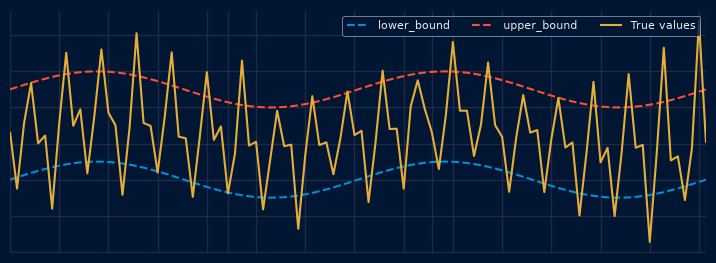

Coverage: 0.67


In [2]:
# Simulate an interval that is too narrow (under-coverage)
# ==============================================================================
rng = np.random.default_rng(42)
interval = pd.DataFrame({
        'lower_bound': np.sin(np.linspace(0, 4 * np.pi, 100)),
        'upper_bound': np.sin(np.linspace(0, 4 * np.pi, 100)) + 5
    },
    index=pd.date_range(start='2024-01-01', periods=100, freq='D')
)
y_true = (interval['lower_bound'] + interval['upper_bound']) / 2 + rng.normal(0, 0.5, 100)
y_true.name = "series_1"
# Push some observations below the lower bound (positions 1, 6, 11, ...) and
# above the upper bound (positions 3, 8, 13, ...)
y_true.iloc[1::5] = interval.iloc[1::5, 0] - rng.normal(1, 1, 20)
y_true.iloc[3::5] = interval.iloc[3::5, 1] + rng.normal(1, 1, 20)

set_dark_theme()
fig, ax = plt.subplots(figsize=(8, 3))
interval.plot(ax=ax, linestyle="--")
y_true.plot(ax=ax, label='True values')
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.legend(loc="upper right", fontsize=8, ncol=3)
plt.show()

coverage = calculate_coverage(
               y_true      = y_true,
               lower_bound = interval["lower_bound"],
               upper_bound = interval["upper_bound"]
           )
print(f'Coverage: {coverage:.2f}')

The interval has a coverage of 67%, which means that the true values are within the interval 67% of the time. Next, the [`ConformalIntervalCalibrator`](https://skforecast.org/latest/api/preprocessing#skforecast.preprocessing._preprocessing.ConformalIntervalCalibrator) transformer is used to calibrate the prediction interval so that it reaches a coverage of 80%.

In [3]:
# Create and fit ConformalIntervalCalibrator
# ==============================================================================
calibrator = ConformalIntervalCalibrator(nominal_coverage=0.8)
calibrator.fit(y_true=y_true, y_pred_interval=interval)
calibrator

=========================== 
ConformalIntervalCalibrator 
=========================== 
Nominal coverage: 0.8 
Coverage in fit data: {'series_1': 0.67} 
Symmetric interval: True 
Symmetric correction factor: {'series_1': 0.8400203828105852} 
Asymmetric correction factor lower: {'series_1': 0.7640361794875151} 
Asymmetric correction factor upper: {'series_1': 1.1833477398578618} 
Fitted series: ['series_1']

The calibrator first measures the coverage of the interval in the data used to fit it (`Coverage in fit data`, stored in the `fit_coverage_` attribute). It then computes, for each observation, a **conformity score**: the distance by which the true value falls outside the interval, $s_i = \max(\text{lower}_i - y_i,\; y_i - \text{upper}_i)$. The score is positive when the observation is outside the interval and negative when it is inside. The symmetric correction factor is the quantile of these scores at the nominal coverage (here, the 80th percentile).

The correction factor of 0.84 means that each bound must be moved 0.84 units away from the center of the interval (the lower bound down and the upper bound up) to achieve the desired coverage of 80%. A positive factor widens the interval, while a negative factor narrows it.

The asymmetric correction factors (`Asymmetric correction factor lower` and `upper`) are computed separately for each bound, using only the scores of that bound. They are applied only when the calibrator is created with `symmetric_calibration=False`, which is useful when the interval fails mainly on one side.

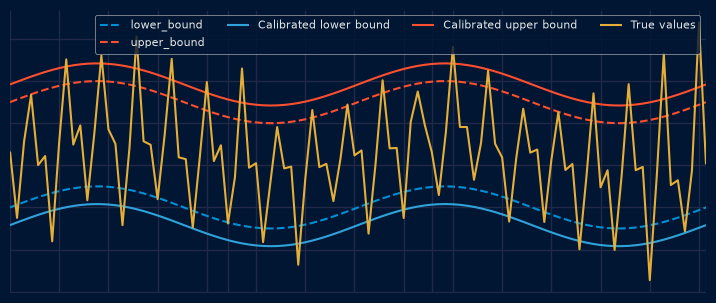

Coverage: 0.80


In [4]:
# Calibrate interval
# ==============================================================================
interval_calibrated = calibrator.transform(interval)

fig, ax = plt.subplots(figsize=(8, 3.5))
interval.plot(ax=ax, linestyle="--")
interval_calibrated["lower_bound"].plot(ax=ax, color="#30a2da", label="Calibrated lower bound")
interval_calibrated["upper_bound"].plot(ax=ax, color="#fc4f30", label="Calibrated upper bound")
y_true.plot(ax=ax, label="True values")
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.legend(loc="upper right", fontsize=8, ncol=4)
plt.show()

coverage = calculate_coverage(
               y_true      = y_true,
               lower_bound = interval_calibrated["lower_bound"],
               upper_bound = interval_calibrated["upper_bound"]
           )
print(f"Coverage: {coverage:.2f}")

After calibration, both bounds are moved 0.84 units away from the center of the interval, and the coverage rises from 0.67 to 0.80, matching the nominal coverage of 80%.

<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161; Tip</b>
</p>

<p>
    For more details on the conformal calibration method, see the FAQ section <a href="../faq/probabilistic-forecasting-calibrate-intervals.html" target="_blank">Calibration of probabilistic forecasting intervals</a>.
</p>

</div>

## Calibration of single series models

A [`ForecasterRecursive`](https://skforecast.org/latest/api/forecasterrecursive) model is used to estimate prediction intervals with the [bootstrapped residuals method](../user_guides/probabilistic-forecasting-bootstrapped-residuals.html). A [`ConformalIntervalCalibrator`](https://skforecast.org/latest/api/preprocessing#skforecast.preprocessing._preprocessing.ConformalIntervalCalibrator) transformer is then used to calibrate the prediction intervals so that they reach the desired coverage probability. This example continues the one in the bootstrapped residuals guide: same data, same partitions and same forecaster, so the calibrated intervals can be compared with those obtained with the other methods on the same test set.

In [5]:
# Data download
# ==============================================================================
data = fetch_dataset(name='bike_sharing', raw=False)
data = data[['users', 'temp', 'hum', 'windspeed', 'holiday']]
data = data.loc['2011-04-01 00:00:00':'2012-10-20 23:00:00', :].copy()
data.head(3)

╭───────────────────────────────── bike_sharing ──────────────────────────────────╮
│ Description:                                                                    │
│ Hourly usage of the bike share system in the city of Washington D.C. during the │
│ years 2011 and 2012. In addition to the number of users per hour, information   │
│ about weather conditions and holidays is available.                             │
│                                                                                 │
│ Source:                                                                         │
│ Fanaee-T,Hadi. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.   │
│ https://doi.org/10.24432/C5W894.                                                │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/bike_sharing_dataset_clean.csv                               │
│                                                                                 │
│ Shape: 17544 rows x 11 columns                                                  │
╰─────────────────────────────────────────────────────────────────────────────────╯

,users,temp,hum,windspeed,holiday
date_time,,,,,
2011-04-01 00:00:00,6.0,10.66,100.0,11.0014,0.0
2011-04-01 01:00:00,4.0,10.66,100.0,11.0014,0.0
2011-04-01 02:00:00,7.0,10.66,93.0,12.9980,0.0


Additional features are created based on calendar information: month, week, day of the week and hour. These variables are cyclical (hour 23 is as close to hour 0 as hour 1 is), so they are encoded with sine and cosine transformations that preserve this continuity.

In [6]:
# Split train-calibration-test
# ==============================================================================
end_train = '2012-06-30 23:59:00'
end_calibration = '2012-10-01 23:59:00'
data_train = data.loc[: end_train, :]
data_cal   = data.loc[end_train:end_calibration, :]
data_test  = data.loc[end_calibration:, :]

print(f"Dates train      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Dates calibration: {data_cal.index.min()} --- {data_cal.index.max()}  (n={len(data_cal)})")
print(f"Dates test       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Dates train      : 2011-04-01 00:00:00 --- 2012-06-30 23:00:00  (n=10968)
Dates calibration: 2012-07-01 00:00:00 --- 2012-10-01 23:00:00  (n=2232)
Dates test       : 2012-10-02 00:00:00 --- 2012-10-20 23:00:00  (n=456)


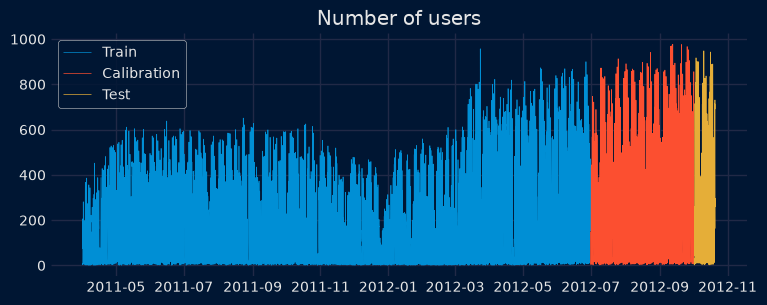

In [7]:
# Plot partitions
# ==============================================================================
plt.rcParams['lines.linewidth'] = 0.5
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(data_train['users'], label='Train')
ax.plot(data_cal['users'], label='Calibration')
ax.plot(data_test['users'], label='Test')
ax.set_title('Number of users')
ax.legend();

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

<p>In this example, the data is divided into three partitions:</p>
<ul>
    <li><b>Training:</b> Used to train the model.</li>
    <li><b>Calibration:</b> Used to determine the correction factor needed to calibrate the prediction intervals. This is the partition called validation set in the bootstrapped residuals guide.</li>
    <li><b>Test:</b> Used to evaluate the calibrated prediction intervals.</li>
</ul>
<p>If hyperparameter optimization or feature selection is required, a fourth partition should be used for validation.</p>

</div>

Prediction intervals are calculated for the test set using the bootstrapped residuals method with in-sample residuals conditioned on the predicted value (binned residuals). Backtesting ([`backtesting_forecaster`](https://skforecast.org/latest/api/model_selection#skforecast.model_selection._validation.backtesting_forecaster) with a [`TimeSeriesFold`](https://skforecast.org/latest/api/model_selection#skforecast.model_selection._split.TimeSeriesFold) partition) is performed to simulate a realistic scenario where the model is trained with historical data and used to forecast future data in successive folds of 24 steps (one day). As shown in the bootstrapped residuals guide, in-sample residuals result in overconfident intervals.

The forecaster is the same as in the [bootstrapped residuals user guide](../user_guides/probabilistic-forecasting-bootstrapped-residuals.html): a `ForecasterRecursive` with a LightGBM regressor that uses as predictors the number of users in the previous 3 hours (lags 1, 2 and 3), the values around the same hour of the previous day (lags 23, 24 and 25) and of the previous week (lags 167, 168 and 169), the mean of the last 72 hours, the calendar features and the exogenous variables. Its hyperparameters were previously optimized with a Bayesian search. Using the same data, partitions and model in the different guides makes it possible to compare the intervals obtained with each method on the same test set.

In [8]:
# Create forecaster
# ==============================================================================
calendar_transformer = CalendarFeatures(
                           features = ['month', 'week', 'day_of_week', 'hour'],
                           encoding = 'cyclical'
                       )
exog_features = ['holiday', 'hum', 'temp', 'windspeed']
params = {
    "max_depth": 7,
    "n_estimators": 300,
    "learning_rate": 0.06,
    "verbose": -1,
    "random_state": 15926
}
lags = [1, 2, 3, 23, 24, 25, 167, 168, 169]
window_features = RollingFeatures(stats=["mean"], window_sizes=24 * 3)

forecaster = ForecasterRecursive(
                 estimator         = LGBMRegressor(**params),
                 lags              = lags,
                 window_features   = window_features,
                 calendar_features = calendar_transformer,
                 binner_kwargs     = {'n_bins': 15}
             )

In [9]:
# Backtesting with prediction intervals in test data using in-sample residuals
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = len(data.loc[:end_calibration]),
         refit              = False
     )

_, predictions_test = backtesting_forecaster(
                          forecaster              = forecaster,
                          y                       = data['users'],
                          exog                    = data[exog_features],
                          cv                      = cv,
                          metric                  = 'mean_absolute_error',
                          interval                = [0.1, 0.9],  # 80% prediction interval
                          interval_method         = 'bootstrapping',
                          n_boot                  = 150,
                          use_in_sample_residuals = True,  # Use in-sample residuals
                          use_binned_residuals    = True   # Residuals conditioned on predicted values
                      )
predictions_test.head(5)

100%|██████████| 19/19 [00:00<00:00, 79.80it/s]

,fold,pred,lower_bound,upper_bound
2012-10-02 00:00:00,0,59.806858,38.444511,78.198434
2012-10-02 01:00:00,0,18.736429,8.704568,31.928207
2012-10-02 02:00:00,0,8.343854,2.792277,15.154949
2012-10-02 03:00:00,0,5.829008,1.923306,10.952809
2012-10-02 04:00:00,0,9.904088,4.093286,16.941026


Coverage: 63.6 %
Area: 40614.62
Winkler score: 285.95


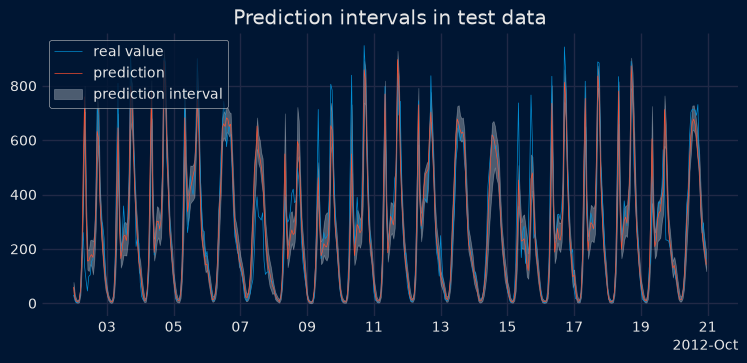

In [10]:
# Coverage, area and Winkler score of the intervals (on test data)
# ==============================================================================
coverage = calculate_coverage(
               y_true      = data_test['users'],
               lower_bound = predictions_test["lower_bound"],
               upper_bound = predictions_test["upper_bound"]
           )
area = (predictions_test["upper_bound"] - predictions_test["lower_bound"]).sum()
winkler = winkler_score(
              y_true      = data_test['users'],
              lower_bound = predictions_test["lower_bound"],
              upper_bound = predictions_test["upper_bound"],
              alpha       = 0.2  # 80% interval -> alpha = 0.2
          )
print(f"Coverage: {round(100 * coverage, 2)} %")
print(f"Area: {round(area, 2)}")
print(f"Winkler score: {round(winkler, 2)}")

# Plot intervals
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 3.5))
plot_prediction_intervals(
    predictions         = predictions_test,
    y_true              = data_test,
    target_variable     = "users",
    title               = "Prediction intervals in test data",
    kwargs_fill_between = {'color': 'white', 'alpha': 0.3, 'zorder': 1},
    ax                  = ax
)

Three metrics are used to evaluate the intervals (see the [metrics user guide](../user_guides/probabilistic-forecasting-metrics.html) for more details):

+ **Coverage** ([`calculate_coverage`](https://skforecast.org/latest/api/metrics#skforecast.metrics.calculate_coverage)): percentage of true values that fall within the interval. For an 80% interval, it should be close to 80%.

+ **Area**: sum of the widths of all the intervals. For the same coverage, a smaller area means sharper, more informative intervals.

+ **Winkler score** ([`winkler_score`](https://skforecast.org/latest/api/metrics#skforecast.metrics.winkler_score)): the width of each interval plus a penalty of $2/\alpha$ times the distance by which the true value falls outside it ($\alpha = 0.2$ for an 80% interval), averaged over all predictions. It rewards narrow intervals and penalizes misses, so lower is better.

The intervals are plotted with [`plot_prediction_intervals`](https://skforecast.org/latest/api/plot#skforecast.plot.plot.plot_prediction_intervals).

As expected, since in-sample residuals are used, the prediction intervals are too narrow: their coverage on the test set is only 63.6%, well below the nominal 80%.

It is common that the prediction intervals obtained with the different methods do not achieve the desired coverage because they are under- or overconfident. Conformal methods allow one to calibrate prediction intervals generated by other techniques, such as quantile regression or bootstrapped residuals. The [`ConformalIntervalCalibrator`](https://skforecast.org/latest/api/preprocessing#skforecast.preprocessing._preprocessing.ConformalIntervalCalibrator) transformer uses the [Split Conformal Prediction (SCP)](https://mapie.readthedocs.io/en/stable/content/conformal-prediction/regression/#2-the-split-method) method to learn the correction factor needed to expand or shrink the prediction intervals so that they are valid with respect to a given coverage probability. The process consists of the following steps:

1. Prediction intervals are estimated for a **calibration set**, a partition of the data not used to train the model (here, with bootstrapping).

2. Using the predicted intervals and the actual values of the calibration set, the `ConformalIntervalCalibrator` transformer learns the **correction factor** needed to calibrate these intervals. For each observation, it computes the conformity score $s_i = \max(\hat{l}_i - y_i,\; y_i - \hat{u}_i)$, where $\hat{l}_i$ and $\hat{u}_i$ are the lower and upper bounds. The score is positive when the true value falls outside the interval and negative when it falls inside. The correction factor $q$ is the quantile of the scores at the nominal coverage (80% in this example).

3. The prediction intervals of new data (in this example, the **test set**) are adjusted using the learned correction factor: $[\hat{l}_i - q,\; \hat{u}_i + q]$.

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff9100;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning</b>
</p>

<p>
It is important to ensure that the calibration set resembles the data on which the intervals will be calibrated (here, the test set). Otherwise, the learned correction factor will not apply well and the resulting calibration will be incorrect.
</p>

</div>

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

<p>The calibration intervals and the test intervals are not produced by exactly the same fitted model. The calibration intervals come from a forecaster trained only with the training partition, since the calibration data must remain unseen by the model that generates them. The test intervals, computed above, come from a forecaster trained with the training and calibration partitions, as would be done before deploying the model.</p>

<p>Strict split conformal prediction uses the same fitted model for calibration and prediction. Here, the correction factor learned with the model trained on less data is assumed to transfer to the model retrained with all the available data. This is a reasonable and common approximation in forecasting, but it is one more reason to verify the coverage of the calibrated intervals on new data.</p>

</div>

In [11]:
# Predict intervals for the calibration set
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = len(data.loc[:end_train]),
         refit              = False
     )

_, predictions_cal = backtesting_forecaster(
                         forecaster              = forecaster,
                         y                       = data.loc[:end_calibration, 'users'],
                         exog                    = data.loc[:end_calibration, exog_features],
                         cv                      = cv,
                         metric                  = 'mean_absolute_error',
                         interval                = [0.1, 0.9],  # 80% prediction interval
                         interval_method         = 'bootstrapping',
                         n_boot                  = 150,
                         use_in_sample_residuals = True,  # Use in-sample residuals
                         use_binned_residuals    = True   # Residuals conditioned on predicted values
                     )

predictions_cal.head(5)

100%|██████████| 93/93 [00:01<00:00, 80.23it/s]

,fold,pred,lower_bound,upper_bound
2012-07-01 00:00:00,0,113.581180,85.752446,138.312497
2012-07-01 01:00:00,0,96.384389,67.501875,122.817302
2012-07-01 02:00:00,0,67.840664,44.562980,99.708332
2012-07-01 03:00:00,0,48.000427,24.338417,69.181144
2012-07-01 04:00:00,0,20.093168,5.040127,32.929690


In [12]:
# Fit a ConformalIntervalCalibrator transformer using the calibration set
# ==============================================================================
calibrator = ConformalIntervalCalibrator(nominal_coverage=0.8)
calibrator.fit(
    y_true          = data_cal['users'],
    y_pred_interval = predictions_cal[['lower_bound', 'upper_bound']]
)
calibrator

=========================== 
ConformalIntervalCalibrator 
=========================== 
Nominal coverage: 0.8 
Coverage in fit data: {'users': 0.6258960573476703} 
Symmetric interval: True 
Symmetric correction factor: {'users': 24.75615813795512} 
Asymmetric correction factor lower: {'users': 3.177857309776222} 
Asymmetric correction factor upper: {'users': 39.10658583151591} 
Fitted series: ['users']

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff9100;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning</b>
</p>

<p>

It is highly recommended to review the coverage observed in the calibration set, stored in the <code>fit_coverage_</code> attribute of the <code>ConformalIntervalCalibrator</code> object. The assumption is that similar coverage will be observed in the test set, allowing the correction factor to be applied effectively.

However, if the coverage differs between the calibration and test sets, the correction factor may not be appropriate. For instance, suppose the nominal coverage is 80%, but the calibration set achieves only 70%. In this case, the calibrator will learn a correction factor that expands the intervals to reach the desired 80% coverage. However, if the test set already has 90% coverage, applying the same correction factor would further widen the intervals instead of shrinking them, resulting in incorrect calibration.

By reviewing the calibration coverage beforehand, you can verify whether the correction factor is valid for the test set, preventing potential miscalibrations.
</p>

</div>

The `ConformalIntervalCalibrator` reports a coverage of 62.6% in the calibration set, well below the nominal 80% and close to the 63.6% observed on the test set before calibration, so the assumption described in the warning above holds. Consequently, the learned correction factor is positive (24.76 users), indicating that the intervals are too narrow and that both bounds must be moved away from the prediction by that amount to achieve the desired coverage.

The asymmetric correction factors provide additional insight: the lower bound needs a small correction (3.18 users), whereas the upper bound needs a much larger one (39.11 users). The intervals fail mainly because the true values exceed the upper bound, most likely at demand peaks that the model underpredicts. With `symmetric_calibration=False`, the calibrator would widen mainly the upper bound, producing narrower intervals than the symmetric correction.

The already calculated prediction intervals of the test set are now calibrated.

In [13]:
# Calibrate prediction intervals of the test set
# ==============================================================================
predictions_test_calibrated = calibrator.transform(
    predictions_test[["lower_bound", "upper_bound"]]
)

print('Prediction intervals before calibration')
print('---------------------------------------')
display(predictions_test[['lower_bound', 'upper_bound']].head(3))

print('Prediction intervals after calibration')
print('--------------------------------------')
predictions_test_calibrated.head(3)

Prediction intervals before calibration
---------------------------------------


,lower_bound,upper_bound
2012-10-02 00:00:00,38.444511,78.198434
2012-10-02 01:00:00,8.704568,31.928207
2012-10-02 02:00:00,2.792277,15.154949


Prediction intervals after calibration
--------------------------------------


,level,lower_bound,upper_bound
2012-10-02 00:00:00,users,13.688353,102.954592
2012-10-02 01:00:00,users,-16.051590,56.684365
2012-10-02 02:00:00,users,-21.963881,39.911107


Coverage: 78.73 %
Area: 63192.24
Winkler score: 267.7


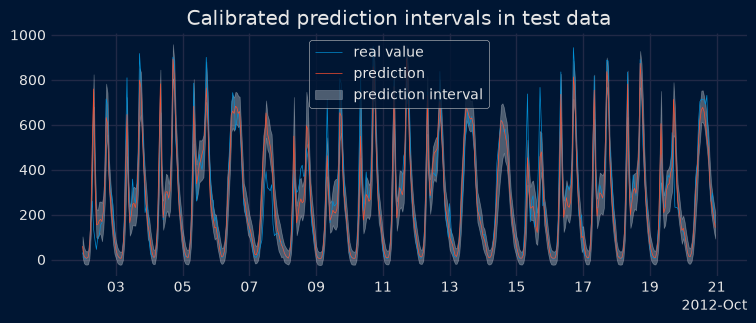

In [14]:
# Plot intervals
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 3))
predictions_test_calibrated['pred'] = predictions_test['pred']
plot_prediction_intervals(
    predictions         = predictions_test_calibrated,
    y_true              = data_test,
    target_variable     = "users",
    title               = "Calibrated prediction intervals in test data",
    kwargs_fill_between = {'color': 'white', 'alpha': 0.3, 'zorder': 1},
    ax                  = ax
)

# Coverage, area and Winkler score of the calibrated intervals (on test data)
# ==============================================================================
coverage = calculate_coverage(
               y_true      = data_test['users'],
               lower_bound = predictions_test_calibrated["lower_bound"],
               upper_bound = predictions_test_calibrated["upper_bound"]
           )
area = (predictions_test_calibrated["upper_bound"] - predictions_test_calibrated["lower_bound"]).sum()
winkler = winkler_score(
              y_true      = data_test['users'],
              lower_bound = predictions_test_calibrated["lower_bound"],
              upper_bound = predictions_test_calibrated["upper_bound"],
              alpha       = 0.2  # 80% interval -> alpha = 0.2
          )
print(f"Coverage: {round(100 * coverage, 2)} %")
print(f"Area: {round(area, 2)}")
print(f"Winkler score: {round(winkler, 2)}")

After calibration, the empirical coverage of the intervals in the test set increases from 63.6% to 78.7%, very close to the nominal coverage of 80%, and the Winkler score improves from 286 to 268. The area grows (from about 40,600 to 63,200) because the intervals had to be widened: the calibration trades sharpness for coverage. On the same test set, the calibrated intervals are comparable with those obtained with out-of-sample residuals in the other guides: conformal prediction with binned residuals reaches 76.8% coverage with an area of about 61,800 and a Winkler score of 258, and bootstrapping with out-of-sample binned residuals reaches 86.4% coverage with an area of about 96,800 and a Winkler score of 267.

Since the correction factor is a constant value applied to all the intervals, the lower bound can take negative values when the predicted number of users is low (see the first rows of the table above). If the target variable cannot be negative, as in this case, the lower bound can be clipped to zero with `predictions_test_calibrated['lower_bound'] = predictions_test_calibrated['lower_bound'].clip(lower=0)`. Clipping does not change the coverage of a non-negative target (no true value lies below zero), it only reduces the area of the intervals.

## Calibration for global models

The same calibration process can be applied to [global models](../user_guides/independent-multi-time-series-forecasting.html) such as [`ForecasterRecursiveMultiSeries`](https://skforecast.org/latest/api/forecasterrecursivemultiseries). In this case, the `ConformalIntervalCalibrator` transformer is fitted with the calibration intervals of multiple series, obtained with [`backtesting_forecaster_multiseries`](https://skforecast.org/latest/api/model_selection#skforecast.model_selection._validation.backtesting_forecaster_multiseries), and it learns a separate correction factor for each series.

The data used in this example is the ETTm2 dataset, which contains measurements of an electricity transformer station recorded every 15 minutes. The data is aggregated to hourly frequency (mean of each hour) and limited to the period between July and October 2016. Three of the load series are forecasted: `HUFL` (High UseFul Load), `HULL` (High UseLess Load) and `MULL` (Middle UseLess Load). The extended version of the dataset already includes calendar features encoded with sine and cosine, which are used as exogenous variables (in the previous section, they were created with [`CalendarFeatures`](https://skforecast.org/latest/api/preprocessing#skforecast.preprocessing._calendar.CalendarFeatures)).

In [15]:
# Data
# ==============================================================================
data = fetch_dataset(name="ett_m2_extended")
data = data.resample(rule="1h", closed="left", label="right").mean()
data = data.loc[:'2016-10-31 23:59:00', :].copy()
data.head(2)

╭──────────────────────────────── ett_m2_extended ─────────────────────────────────╮
│ Description:                                                                     │
│ Data from an electricity transformer station was collected between July 2016 and │
│ July 2018 (2 years x 365 days x 24 hours x 4 intervals per hour = 70,080 data    │
│ points). Each data point consists of 8 features, including the date of the       │
│ point, the predictive value "Oil Temperature (OT)", and 6 different types of     │
│ external power load features: High UseFul Load (HUFL), High UseLess Load (HULL), │
│ Middle UseFul Load (MUFL), Middle UseLess Load (MULL), Low UseFul Load (LUFL),   │
│ Low UseLess Load (LULL). Additional variables are created based on calendar      │
│ information (year, month, week, day of the week, and hour). These variables have │
│ been encoded using the cyclical encoding technique (sin and cos transformations) │
│ to preserve the cyclical nature of the data.                                     │
│                                                                                  │
│ Source:                                                                          │
│ Zhou, Haoyi & Zhang, Shanghang & Peng, Jieqi & Zhang, Shuai & Li, Jianxin &      │
│ Xiong, Hui & Zhang, Wancai. (2020). Informer: Beyond Efficient Transformer for   │
│ Long Sequence Time-Series Forecasting.                                           │
│ [10.48550/arXiv.2012.07436](https://arxiv.org/abs/2012.07436).                   │
│ https://github.com/zhouhaoyi/ETDataset                                           │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/ETTm2_extended.csv                                            │
│                                                                                  │
│ Shape: 69680 rows x 16 columns                                                   │
╰──────────────────────────────────────────────────────────────────────────────────╯

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT,year,month_sin,month_cos,week_sin,week_cos,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
date,,,,,,,,,,,,,,,,
2016-07-01 01:00:00,38.784501,10.88975,34.753500,8.551,4.12575,1.2605,37.83825,2016.0,-0.5,-0.866025,1.224647e-16,-1.0,-0.433884,-0.900969,0.000000,1.000000
2016-07-01 02:00:00,36.041249,9.44475,32.696001,7.137,3.59025,0.6290,36.84925,2016.0,-0.5,-0.866025,1.224647e-16,-1.0,-0.433884,-0.900969,0.258819,0.965926


In [16]:
# Split data into: train-calibration-test
# ==============================================================================
series = ['HUFL', 'HULL', 'MULL']  # Series to forecast
end_train = '2016-08-31 23:59:00'
end_calibration = '2016-09-30 23:59:00'
data_train = data.loc[: end_train, :]
data_cal   = data.loc[end_train:end_calibration, :]
data_test  = data.loc[end_calibration:, :]

print(f"Dates train      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Dates calibration: {data_cal.index.min()} --- {data_cal.index.max()}  (n={len(data_cal)})")
print(f"Dates test       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Dates train      : 2016-07-01 01:00:00 --- 2016-08-31 23:00:00  (n=1487)
Dates calibration: 2016-09-01 00:00:00 --- 2016-09-30 23:00:00  (n=720)
Dates test       : 2016-10-01 00:00:00 --- 2016-10-31 23:00:00  (n=744)


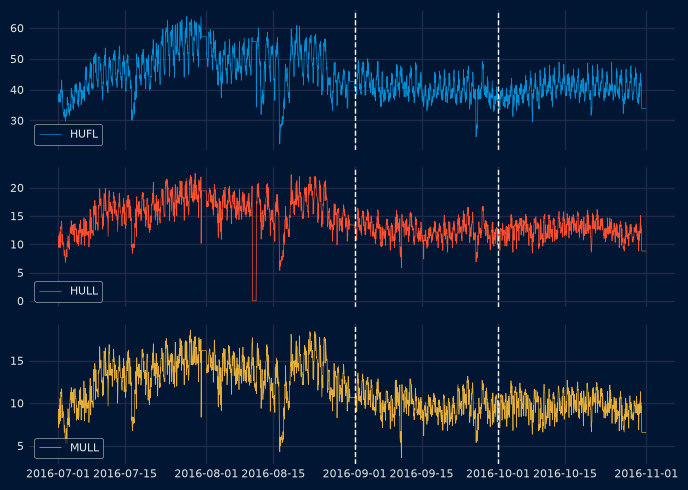

In [17]:
# Plot partitions
# ==============================================================================
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axs = plt.subplots(3, 1, figsize=(7, 5), sharex=True)
for i, col in enumerate(series):
    axs[i].plot(data[col], label=col, color=colors[i])
    axs[i].legend(loc='lower left', fontsize=8)
    axs[i].tick_params(axis='both', labelsize=8)
    axs[i].axvline(pd.to_datetime(end_train), color='white', linestyle='--', linewidth=1)  # End train
    axs[i].axvline(pd.to_datetime(end_calibration), color='white', linestyle='--', linewidth=1)  # End calibration

plt.tight_layout()
plt.show()

A global [`ForecasterRecursiveMultiSeries`](https://skforecast.org/latest/api/forecasterrecursivemultiseries) is trained with a `Ridge` regressor for the three series. Each series is scaled with a `StandardScaler` (`transformer_series`), as are the exogenous variables (`transformer_exog`), and the series are differentiated once (`differentiation=1`) so that the model learns the changes between consecutive hours rather than the levels. The series identifier is included as a feature with `encoding='ordinal'`. As in the first example, the bootstrapped residuals are conditioned on the predicted value, in this case with 5 bins (`binner_kwargs`).

In [18]:
# Create forecaster
# ==============================================================================
exog_features = [
    'year', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'day_of_week_sin',
    'day_of_week_cos', 'hour_sin', 'hour_cos'
]
lags = [1, 3, 11, 12, 13, 14, 15, 17, 23, 24, 25, 49, 73, 97, 145]

forecaster = ForecasterRecursiveMultiSeries(
                 estimator          = Ridge(),
                 lags               = lags,
                 encoding           = 'ordinal',
                 transformer_series = StandardScaler(),
                 transformer_exog   = StandardScaler(),
                 differentiation    = 1,
                 binner_kwargs      = {'n_bins': 5}
             )

In [19]:
# Backtesting on test data using in-sample residuals
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = len(data.loc[:end_calibration, :]),
         refit              = False,
         differentiation    = 1  # Must match the forecaster's differentiation
     )

_, predictions_test = backtesting_forecaster_multiseries(
                          forecaster              = forecaster,
                          series                  = data.loc[:, series],
                          exog                    = data.loc[:, exog_features],
                          cv                      = cv,
                          metric                  = 'mean_absolute_error',
                          interval                = [0.1, 0.9],  # 80% prediction interval
                          interval_method         = 'bootstrapping',
                          n_boot                  = 150,
                          use_in_sample_residuals = True,  # Use in-sample residuals
                          use_binned_residuals    = True,  # Residuals conditioned on predicted values
                          suppress_warnings       = True   # Hide InputTypeWarning (wide DataFrame as series)
                      )

100%|██████████| 31/31 [00:01<00:00,  8.43it/s]

In [20]:
# Coverage, area and Winkler score for each level (before calibration)
# ==============================================================================
for level in predictions_test["level"].unique():
    predictions_level = (
        predictions_test[predictions_test["level"] == level]
        .drop(columns="level")
    )
    coverage = calculate_coverage(
                   y_true      = data_test[level],
                   lower_bound = predictions_level["lower_bound"],
                   upper_bound = predictions_level["upper_bound"]
               )
    area = (predictions_level["upper_bound"] - predictions_level["lower_bound"]).sum()
    winkler = winkler_score(
                  y_true      = data_test[level],
                  lower_bound = predictions_level["lower_bound"],
                  upper_bound = predictions_level["upper_bound"],
                  alpha       = 0.2  # 80% interval -> alpha = 0.2
              )
    print(
        f"{level} - Coverage: {round(100 * coverage, 2)} % - Area: {round(area, 2)} "
        f"- Winkler score: {round(winkler, 2)}"
    )

HUFL - Coverage: 96.24 % - Area: 11094.31 - Winkler score: 15.28
HULL - Coverage: 97.58 % - Area: 6712.73 - Winkler score: 9.15
MULL - Coverage: 96.77 % - Area: 5473.82 - Winkler score: 7.49


In this example, even though the intervals are calculated using in-sample residuals, the coverage is much higher than the nominal 80% (96.2%, 97.6% and 96.8%), so the intervals are too wide. This is the opposite of what happened with the LightGBM model of the previous section, and it is likely due to two reasons:

+ A linear model such as `Ridge` hardly overfits the training data, so its in-sample residuals are not much smaller than the errors it makes on new data.

+ Since the series are differentiated, the bootstrapped errors are accumulated when the predictions are transformed back to the original scale, which widens the intervals as the forecast horizon grows.

Next, the intervals are calibrated using the `ConformalIntervalCalibrator` transformer.

In [21]:
# Backtesting on calibration set
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 24,
         initial_train_size = len(data.loc[:end_train, :]),
         refit              = False,
         differentiation    = 1  # Must match the forecaster's differentiation
     )

_, predictions_cal = backtesting_forecaster_multiseries(
                         forecaster              = forecaster,
                         series                  = data.loc[:end_calibration, series],
                         exog                    = data.loc[:end_calibration, exog_features],
                         cv                      = cv,
                         metric                  = 'mean_absolute_error',
                         interval                = [0.1, 0.9],  # 80% prediction interval
                         interval_method         = 'bootstrapping',
                         n_boot                  = 150,
                         use_in_sample_residuals = True,  # Use in-sample residuals
                         use_binned_residuals    = True,  # Residuals conditioned on predicted values
                         suppress_warnings       = True   # Hide InputTypeWarning (wide DataFrame as series)
                     )

100%|██████████| 30/30 [00:00<00:00, 2533.81it/s]

In [22]:
# Create and fit ConformalIntervalCalibrator
# ==============================================================================
calibrator = ConformalIntervalCalibrator(nominal_coverage=0.8)
calibrator.fit(
    y_true          = data_cal[series],
    y_pred_interval = predictions_cal
)
calibrator

=========================== 
ConformalIntervalCalibrator 
=========================== 
Nominal coverage: 0.8 
Coverage in fit data: {'HUFL': 0.9694444444444444, 'HULL': 0.9833333333333333, 'MULL': 0.9680555555555556} 
Symmetric interval: True 
Symmetric correction factor: {'HUFL': -2.7878517209863842, 'HULL': -1.9653641691186907, 'MULL': -1.4805341783221277} 
Asymmetric correction factor lower: {'HUFL': -2.090525169341023, 'HULL': -1.383063856197737, 'MULL': -0.9309778691566541} 
Asymmetric correction factor upper: {'HUFL': -3.5702368376893125, 'HULL': -2.5786524357616645, 'MULL': -1.975576082075763} 
Fitted series: ['HUFL', 'HULL', 'MULL']

The symmetric correction factor of all levels is negative (-2.79, -1.97 and -1.48), which means that the prediction intervals are too wide and need to be narrowed to achieve the desired coverage probability.

As recommended in the warning of the previous section, the coverage observed in the calibration set (96.9%, 98.3% and 96.8%) is compared with the coverage expected for the new intervals. In this case, it is very close to the coverage of the uncalibrated test intervals (96.2%, 97.6% and 96.8%), so the correction factors learned in the calibration set are expected to be valid for the test set. The prediction intervals of the test set are now calibrated, which narrows them.

In [23]:
# Calibrate prediction intervals of the test set
# ==============================================================================
predictions_test_calibrated = calibrator.transform(predictions_test)
predictions_test_calibrated.head(3)

,level,lower_bound,upper_bound
2016-10-01 00:00:00,HUFL,35.454979,36.846566
2016-10-01 01:00:00,HUFL,34.322673,34.918745
2016-10-01 02:00:00,HUFL,32.518754,33.994147


HUFL - Coverage: 79.84 % - Area: 7044.41 - Winkler score: 12.45
HULL - Coverage: 77.69 % - Area: 3855.71 - Winkler score: 7.11
MULL - Coverage: 77.42 % - Area: 3341.42 - Winkler score: 6.16


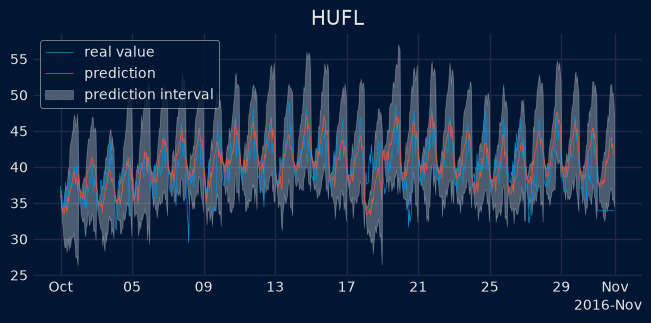

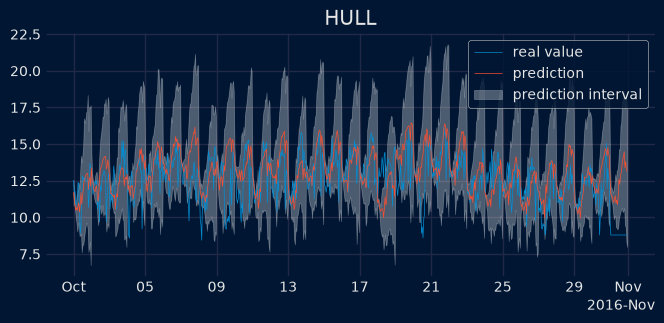

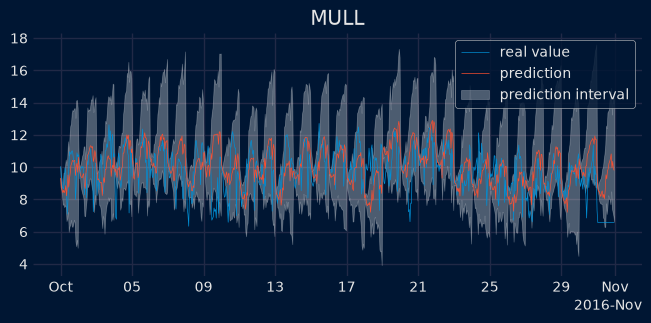

In [24]:
# Prediction intervals on test data after calibration
# ==============================================================================
for level in predictions_test_calibrated["level"].unique():
    predictions_level = (
        predictions_test_calibrated[predictions_test_calibrated["level"] == level]
        .drop(columns="level")
        .copy()
    )
    predictions_level['pred'] = predictions_test.loc[predictions_test['level'] == level, 'pred']

    plot_prediction_intervals(
        predictions         = predictions_level,
        y_true              = data_test[[level]],
        target_variable     = level,
        title               = level,
        kwargs_fill_between = {'color': 'white', 'alpha': 0.3, 'zorder': 1}
    )
    coverage = calculate_coverage(
                   y_true      = data_test[level],
                   lower_bound = predictions_level["lower_bound"],
                   upper_bound = predictions_level["upper_bound"]
               )
    area = (predictions_level["upper_bound"] - predictions_level["lower_bound"]).sum()
    winkler = winkler_score(
                  y_true      = data_test[level],
                  lower_bound = predictions_level["lower_bound"],
                  upper_bound = predictions_level["upper_bound"],
                  alpha       = 0.2  # 80% interval -> alpha = 0.2
              )
    print(
        f"{level} - Coverage: {round(100 * coverage, 2)} % - Area: {round(area, 2)} "
        f"- Winkler score: {round(winkler, 2)}"
    )

After calibration, the coverage of the three series is close to the nominal 80% (79.8%, 77.7% and 77.4%) and the intervals are considerably narrower: the area decreases by 37%, 43% and 39%, respectively (for example, from 11,094 to 7,044 for `HUFL`). The Winkler score also improves (from 15.28, 9.15 and 7.49 to 12.45, 7.11 and 6.16), since the narrower intervals are rewarded more than the few additional misses are penalized.

**Key takeaways**

+ Conformal calibration can correct intervals that are too narrow (positive correction factor) or too wide (negative correction factor), regardless of the method used to generate them.

+ The calibration set must not be used to train the model that produces the calibration intervals, and it should resemble the data whose intervals are calibrated.

+ Review the coverage observed in the calibration data (`fit_coverage_`) before applying the correction factor to new intervals.

+ When the intervals fail mainly on one side, `symmetric_calibration=False` applies a different correction to each bound.

+ A constant correction can produce impossible values (for example, negative counts). Clip the bounds when the target variable has natural limits.